In [188]:
from graphviz import Digraph
import numpy as np
import pandas as pd
from IPython.display import display

In [189]:
def compute_entropy(y):
    if len(y) == 0:
        return 0
    entropy = np.sum(y) / len(y)
    if entropy in [0, 1]:
        return 0
    else:
        return -entropy * np.log2(entropy) - (1 - entropy) * np.log2(1 - entropy)

In [190]:
def split_dataset(X, node_indices, feature):
    left_indices = []
    right_indices = []
    
    for i in node_indices:
        if i < len(X): 
            if X[i][feature] == 1:
                left_indices.append(i)
            else:
                right_indices.append(i)
        else:
            print(f"Index {i} is out of bounds for dataset of size {len(X)}")
    return left_indices, right_indices


In [191]:
def compute_information_gain(X, y, node_indices, feature):
    left_indices, right_indices = split_dataset(X, node_indices, feature)
    
    X_node, y_node = X[node_indices], y[node_indices]
    X_left, y_left = X[left_indices], y[left_indices]
    X_right, y_right = X[right_indices], y[right_indices]
    
    node_entropy = compute_entropy(y_node)
    left_entropy = compute_entropy(y_left)
    right_entropy = compute_entropy(y_right)

    w_left = len(X_left) / len(X_node)
    w_right = len(X_right) / len(X_node)
    weighted_entropy = w_left * left_entropy + w_right * right_entropy
    
    return node_entropy - weighted_entropy

In [192]:
def get_best_split(X, y, node_indices):   
    num_features = X.shape[1]
    best_feature = -1
    max_info_gain = 0
    for feature in range(num_features):
        info_gain = compute_information_gain(X, y, node_indices, feature)
        if info_gain > max_info_gain:
            max_info_gain = info_gain
            best_feature = feature
    return best_feature

In [193]:
def build_tree_recursive(X, y, node_indices, branch_name, max_depth, current_depth, tree):
    if current_depth == max_depth:
        formatting = " " * current_depth + "-" * current_depth
        print(formatting, "%s leaf node with indices" % branch_name, node_indices)
        return
   
    best_feature = get_best_split(X, y, node_indices) 
    formatting = "-" * current_depth
    print("%s Depth %d, %s: Split on feature: %d" % (formatting, current_depth, branch_name, best_feature))

    left_indices, right_indices = split_dataset(X, node_indices, best_feature)
    tree.append((left_indices, right_indices, best_feature))
    
    build_tree_recursive(X, y, left_indices, "Left", max_depth, current_depth + 1, tree)
    build_tree_recursive(X, y, right_indices, "Right", max_depth, current_depth + 1, tree)
    return tree

In [194]:
def generate_tree_viz(root_indices, y, tree, feature_names, y_names):
    dot = Digraph()  # Cập nhật tên nhãn nếu cần
    
    def add_node(indices, node_id):
        if len(indices) == 0:
            return
        
        if len(set(y[indices])) == 1:
            leaf_label = f"Leaf\nIndices: {(indices)}\n {y_name[y[indices][0]]}"
            dot.node(str(node_id), leaf_label, shape='box', style='filled', color='lightgrey')
        else:
            label = f"Samples: {(indices)}"
            dot.node(str(node_id), label)
        
        if node_id < len(tree):
            left_indices, right_indices, feature = tree[node_id]
            if left_indices:
                left_id = node_id * 2 + 1
                dot.edge(str(node_id), str(left_id), f"{feature_names[feature]} = 1")
                add_node(left_indices, left_id)
            if right_indices:
                right_id = node_id * 2 + 2
                dot.edge(str(node_id), str(right_id), f"{feature_names[feature]} = 0")
                add_node(right_indices, right_id)
    
    add_node(root_indices, 0)
    return dot

In [195]:
x_train = np.array(
    [
        [1, 1, 1],
        [1, 0, 1],
        [1, 0, 0],
        [1, 0, 0],
        [1, 1, 1],
        [0, 1, 1],
        [0, 0, 0],
        [1, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
    ]
)
y_train = np.array([1, 1, 0, 0, 1, 0, 0, 1, 1, 0])
feature_names = ["Cap Color", "Stalk Shape", "Solitory"]
y_names = ["Non Edible","Edible"]
node_indices = list(range(len(y_train)))
tree = []

 Depth 0, Root: Split on feature: 2
- Depth 1, Left: Split on feature: 0
  -- Left leaf node with indices [0, 1, 4, 7]
  -- Right leaf node with indices [5]
- Depth 1, Right: Split on feature: 1
  -- Left leaf node with indices [8]
  -- Right leaf node with indices [2, 3, 6, 9]


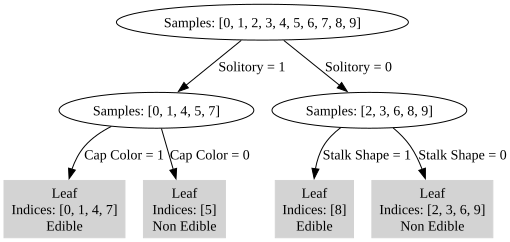

In [196]:
build_tree_recursive(x_train, y_train, node_indices, "Root", max_depth=2, current_depth=0, tree=tree)
tree_viz = generate_tree_viz(node_indices, y_train, tree, feature_names, y_names)
display(tree_viz)